# Aumentación 3D con HA-GAN para OASIS para Clase Very Mild Dementia

Se generarán volúmenes 3D sintéticos de la clase VMD (CDR=0.5) usando el modelo HA-GAN pre-entrenado en el dataset de cerebros GSP, con fine-tuning sobre los sujetos VMD del conjunto de entrenamiento, para mitigar el desbalance de clases (135 sanos vs 70 VMD).


## 0. Clonar repo para utilizar la GAN preentrenada e instalaciones adaptadas para colab
Clonar el repo donde está la GAN que se va a utilizar, instalar dependencias y descargar el checkpoint GSP Brain MRI pre-entrenado.

In [ ]:
import subprocess, sys, os

try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive')

    if not os.path.exists('/content/HA-GAN'):
        subprocess.run(
            ['git', 'clone', 'https://github.com/batmanlab/HA-GAN.git', '/content/HA-GAN'],
            check=True
        )
    subprocess.run(
        [sys.executable, '-m', 'pip', 'install', '-q', 'nibabel', 'scipy', 'scikit-learn', 'openpyxl', 'gdown', 'tensorboardX', 'nilearn'],
        check=True
    )
    sys.path.insert(0, '/content/HA-GAN')
    HAGAN_DIR  = '/content/HA-GAN'
    OUTPUT_DIR = '/content/drive/MyDrive/Proyecto imagenes y vision/OASIS_Augmentation'

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'IN_COLAB  : {IN_COLAB}')
print(f'HAGAN_DIR : {HAGAN_DIR}')
print(f'OUTPUT_DIR: {OUTPUT_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
IN_COLAB  : True
HAGAN_DIR : /content/HA-GAN
OUTPUT_DIR: /content/drive/MyDrive/Proyecto imagenes y vision/OASIS_Augmentation


Para evitar el costo computacional de entrenar la red HA-GAN desde cero, se descarga un modelo preentrenado (checkpoint) de GSP Brain MRI.

In [ ]:
import gdown

GSP_FILE_ID  = '10AcfBPB_Tnjgy9bSj1qcZTW1s7qTIWRM'
GSP_CKPT_PATH = os.path.join(OUTPUT_DIR, 'gsp_pretrained.pth')

if not os.path.exists(GSP_CKPT_PATH):
    print('Descargando checkpoint GSP Brain MRI...')
    gdown.download(f'https://drive.google.com/uc?id={GSP_FILE_ID}', GSP_CKPT_PATH, quiet=False)
else:
    print(f'Checkpoint ya existe: {GSP_CKPT_PATH}')

print(f'Tamaño: {os.path.getsize(GSP_CKPT_PATH) / 1e6:.1f} MB')

Checkpoint ya existe: /content/drive/MyDrive/Proyecto imagenes y vision/OASIS_Augmentation/gsp_pretrained.pth
Tamaño: 296.0 MB


## 1. Importaciones y Configuración de Paths

Se definen las rutas de los directorios de entrada y de salida. Finalmente, se establecen los hiperparámetros de la red generativa

In [ ]:
import nibabel as nib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import warnings
from scipy.ndimage import zoom
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

if IN_COLAB:
    DISCS_ROOT = '/content/drive/MyDrive/Proyecto imagenes y vision/discs'
    CSV_PATH   = '/content/drive/MyDrive/Proyecto imagenes y vision/oasis_cross-sectional-5708aa0a98d82080.xlsx'

VMD_NPY_DIR    = os.path.join(OUTPUT_DIR, 'vmd_npy_256')        # .npy para fine-tuning HA-GAN
SYNTH_NII_DIR  = os.path.join(OUTPUT_DIR, 'synthetic_vmd')      # .nii.gz generados
CKPT_FINETUNE  = os.path.join(OUTPUT_DIR, 'ha_gan_vmd_finetune') # checkpoints del fine-tuning

for d in [VMD_NPY_DIR, SYNTH_NII_DIR, CKPT_FINETUNE]:
    os.makedirs(d, exist_ok=True)

# Parámetros HA-GAN
IMG_SIZE    = 256   # lo rqeuiere el checkpoint GSP
TARGET_SIZE = (IMG_SIZE, IMG_SIZE, IMG_SIZE)
LATENT_DIM  = 1024  # dim del vector de ruido del generador HA-GAN

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print('Configuración cargada.')
print(f'  DISCS_ROOT   : {DISCS_ROOT}')
print(f'  CSV_PATH     : {CSV_PATH}')
print(f'  IMG_SIZE GAN : {IMG_SIZE}x{IMG_SIZE}x{IMG_SIZE}')
print(f'  OUTPUT_DIR   : {OUTPUT_DIR}')

Configuración cargada.
  DISCS_ROOT   : /content/drive/MyDrive/Proyecto imagenes y vision/discs
  CSV_PATH     : /content/drive/MyDrive/Proyecto imagenes y vision/oasis_cross-sectional-5708aa0a98d82080.xlsx
  IMG_SIZE GAN : 256x256x256
  OUTPUT_DIR   : /content/drive/MyDrive/Proyecto imagenes y vision/OASIS_Augmentation


## 2. Partición Estratificada de Sujetos (Train / Val / Test)

La partición se realiza a nivel de sujeto para evitar data leakage. Se realiza una limpieza en los identificadores para obtener el ID base del sujeto, agrupando los registros para evitar duplicidades de un mismo paciente. Posteriormente, se filtra el conjunto de datos para conservar únicamente las dos clases de interés sujetos sanos (CDR = 0.0) y sujetos con demencia muy leve / Very Mild Dementia (CDR = 0.5).

## **No correr seccion 2** (vuelve a generar el split), correr solo la ultima celda de esta seccion

In [ ]:
df_full = pd.read_excel(CSV_PATH)

# Extraer ID de sujeto base (sin el sufijo _MR1, _MR2, etc.)
df_full['subject_base'] = df_full['ID'].str.extract(r'(OAS1_\d+)')[0]

# Filtrar solo CDR 0 y CDR 0.5 (sano y VMD)
df = df_full[df_full['CDR'].isin([0.0, 0.5])].copy()
df['label'] = df['CDR'].map({0.0: 'sano', 0.5: 'vmd'})

# Agrupar por sujeto base y tomar CDR y label del primer registro
df_subj = df.groupby('subject_base').agg(
    ID=('ID', 'first'),
    CDR=('CDR', 'first'),
    label=('label', 'first')
).reset_index()

print(f'Total de sujetos relevantes: {len(df_subj)}')
print(df_subj['label'].value_counts().to_string())

Total de sujetos relevantes: 205
label
sano    135
vmd      70


Se divide el conjunto de datos a nivel de sujeto en tres subconjuntos Entrenamiento (70%), Validación (15%) y Prueba (15%). Esta partición se realiza de forma estratificada, asegurando que la proporción original entre sujetos sanos y casos VMD se mantenga en todos los conjuntos. La distribución resultante se exporta a un archivo CSV (splits_subjects.csv) para hacer que los modelos 2D y 3D se evalúen bajo las mismas condiciones exactas. Finalmente, se calcula el número de casos VMD sintéticos que la HA-GAN deberá generar para balancear  la clase minoritaria en el conjunto de entrenamiento.

In [ ]:
# Split 70/15/15

# separar train (70%) del resto (30%)
df_train, df_temp = train_test_split(
    df_subj,
    test_size=0.30,
    stratify=df_subj['label'],
    random_state=RANDOM_SEED
)

#  separar val (15%) y test (15%) del 30% restante
df_val, df_test = train_test_split(
    df_temp,
    test_size=0.50,
    stratify=df_temp['label'],
    random_state=RANDOM_SEED
)

df_train = df_train.copy(); df_train['split'] = 'train'
df_val   = df_val.copy();   df_val['split']   = 'val'
df_test  = df_test.copy();  df_test['split']  = 'test'

df_splits = pd.concat([df_train, df_val, df_test]).reset_index(drop=True)

# Guardar partición para reusarla en 2D
SPLIT_CSV = os.path.join(OUTPUT_DIR, 'splits_subjects.csv')
df_splits.to_csv(SPLIT_CSV, index=False)

summary = df_splits.groupby(['split', 'label']).size().unstack(fill_value=0)
summary['total'] = summary.sum(axis=1)
summary['ratio_sano_vmd'] = (summary.get('sano', 0) / summary.get('vmd', 1)).round(2)
print('\nPartición estratificada:')
print(summary.to_string())
print(f'\nSplit guardado en: {SPLIT_CSV}')

n_vmd_train  = (df_splits.query("split=='train' and label=='vmd'")).shape[0]
n_sano_train = (df_splits.query("split=='train' and label=='sano'")).shape[0]
n_needed     = n_sano_train - n_vmd_train
n_generate   = n_needed + 15  # generar 15 extra para descartar malos

print(f'\nVMD en train : {n_vmd_train}')
print(f'Sano en train: {n_sano_train}')
print(f'Sintéticos a generar: ~{n_generate} (se descartan los de menor calidad)')


Partición estratificada:
label  sano  vmd  total  ratio_sano_vmd
split                                  
test     21   10     31            2.10
train    94   49    143            1.92
val      20   11     31            1.82

Split guardado en: /content/drive/MyDrive/Proyecto imagenes y vision/OASIS_Augmentation/splits_subjects.csv

VMD en train : 49
Sano en train: 94
Sintéticos a generar: ~60 (se descartan los de menor calidad)


## **No correr seccion 2** (vuelve a generar el split), correr solo esta celda

In [ ]:
SPLIT_CSV = os.path.join(OUTPUT_DIR, 'splits_subjects.csv')

assert os.path.exists(SPLIT_CSV), (
    f'No se encontró el archivo de splits en: {SPLIT_CSV}\n'
    'Solo ejecutar las celdas de Sección 2 si nunca se ha generado el split.'
)

df_splits = pd.read_csv(SPLIT_CSV)

df_splits['subject_base'] = df_splits['subject_base'].astype(str).str.strip()
df_splits['ID']           = df_splits['ID'].astype(str).str.strip()
df_splits['label']        = df_splits['label'].astype(str).str.strip().str.lower()
df_splits['split']        = df_splits['split'].astype(str).str.strip().str.lower()

df_train = df_splits[df_splits['split'] == 'train'].copy()
df_val   = df_splits[df_splits['split'] == 'val'].copy()
df_test  = df_splits[df_splits['split'] == 'test'].copy()

n_vmd_train  = (df_splits.query("split=='train' and label=='vmd'")).shape[0]
n_sano_train = (df_splits.query("split=='train' and label=='sano'")).shape[0]
n_needed     = n_sano_train - n_vmd_train
n_generate   = n_needed + 15

df_vmd_train = df_splits.query("split=='train' and label=='vmd'").copy()

leakage = df_splits.groupby('subject_base')['split'].nunique()
assert (leakage > 1).sum() == 0, 'ERROR: hay sujetos asignados a más de un split.'

print(f'Split cargado desde: {SPLIT_CSV}')
print(f'Total sujetos: {len(df_splits)}')
print()
print(pd.crosstab(df_splits['split'], df_splits['label'], margins=True).to_string())
print()
print(f'n_vmd_train  : {n_vmd_train}')
print(f'n_sano_train : {n_sano_train}')
print(f'Sintéticos a generar: ~{n_generate}')

Split cargado desde: /content/drive/MyDrive/Proyecto imagenes y vision/OASIS_Augmentation/splits_subjects.csv
Total sujetos: 205

label  sano  vmd  All
split                
test     21   10   31
train    94   49  143
val      20   11   31
All     135   70  205

n_vmd_train  : 49
n_sano_train : 94
Sintéticos a generar: ~60


## 3. Preprocesamiento de Volúmenes VMD para HA-GAN

Para que HA-GAN acepte los volúmenes OASIS, cada sujeto VMD de train se transforma con los siguientes pasos:

1. Localizar y cargar el archivo .hdr terminado en _t88_masked_gfc dentro de la ruta PROCESSED/MPRAGE/T88_111 del sujeto, leyéndolo con nibabel como un volumen float32.
2. Construir una máscara de tejido tomando los vóxeles con intensidad mayor que cero, de modo que el fondo quede excluido de la normalización.
3. Calcular un z-score usando únicamente la media y la desviación estándar de los vóxeles de tejido, y aplicar esa normalización a todo el volumen.
4. Redimensionar el volumen y la máscara de su forma original (176, 208, 176) a (256, 256, 256) usando interpolación lineal.
5. Anclar el fondo en el valor -1 y reescalar linealmente los vóxeles de tejido al rango (-1, 1] a partir de su mínimo y máximo, recortando cualquier valor fuera de [-1, 1].
6. Guardar el volumen resultante como archivo .npy en el directorio de datos para el fine-tuning.

HA-GAN genera volúmenes a (256, 256, 256) porque el checkpoint GSP fue entrenado a esa resolución, y la convención de fondo en -1 con tejido en (-1, 1] es la entrada esperada por el modelo.

In [ ]:
def find_t88_path(subject_id, discs_root):
    pattern = os.path.join(
        discs_root, '**', subject_id, 'PROCESSED', 'MPRAGE', 'T88_111',
        '*_t88_masked_gfc.hdr'
    )
    results = glob.glob(pattern, recursive=True)
    return results[0] if results else None


def preprocess_for_hagan(hdr_path, target_size=(256, 256, 256)):
    """
    Carga un volumen T88 masked GFC y lo prepara para HA-GAN.
    Retorna: array float32 en [-1, 1] de shape target_size,
    con el en -1 y el tejido en (-1, 1].

    Esto es lo que espera el checkpoint GSP.
    """
    img  = nib.load(hdr_path)
    data = np.squeeze(img.get_fdata()).astype(np.float32)

    #  excluye fondo
    mask = data > 0

    #  Z-score sobre vóxeles de tejido
    tissue = data[mask]
    mu, sigma = tissue.mean(), tissue.std()
    if sigma > 0:
        data_z = (data - mu) / sigma
    else:
        data_z = data.copy()

    factors    = [t / s for t, s in zip(target_size, data.shape)]
    data_z     = zoom(data_z, factors, order=1)
    mask_rz    = zoom(mask.astype(np.float32), factors, order=1) > 0.5

    out = np.full(target_size, -1.0, dtype=np.float32)   # fondo = -1

    tissue_vals = data_z[mask_rz]
    if tissue_vals.size > 0:
        t_min, t_max = tissue_vals.min(), tissue_vals.max()
        if t_max > t_min:
            # tejido -> rango (-1, 1]
            scaled = 2.0 * (data_z - t_min) / (t_max - t_min) - 1.0
            out[mask_rz] = np.clip(scaled[mask_rz], -1.0, 1.0)
        else:
            out[mask_rz] = 0.0

    return out.astype(np.float32)


print('Funciones de preprocesamiento definidas (fondo anclado en -1).')

Funciones de preprocesamiento definidas (fondo anclado en -1).


Ahora se itera sobre los sujetos diagnosticados con Very Mild Dementia (VMD) que pertenecen al subconjunto de entrenamiento. Para cada sujeto se localiza el volumen original, se aplica el preprocesamiento definido arriba y se guarda en formato .npy de NumPy, que permite una lectura más rápida en memoria durante el fine-tuning; si el archivo .npy ya existe, se reutiliza sin recalcularlo.

In [ ]:
df_vmd_train = df_splits.query("split=='train' and label=='vmd'").copy()

stats_preprocess = []
skipped = []

for _, row in df_vmd_train.iterrows():
    subject_id = row['ID']
    hdr_path = find_t88_path(subject_id, DISCS_ROOT)

    if hdr_path is None:
        skipped.append(subject_id)
        continue

    out_path = os.path.join(VMD_NPY_DIR, f'{subject_id}.npy')

    if os.path.exists(out_path):
        vol = np.load(out_path)
    else:
        vol = preprocess_for_hagan(hdr_path, TARGET_SIZE)
        np.save(out_path, vol)

    stats_preprocess.append({
        'subject': subject_id,
        'shape': vol.shape,
        'min': round(float(vol.min()), 4),
        'max': round(float(vol.max()), 4),
        'mean': round(float(vol.mean()), 4),
        'std': round(float(vol.std()), 4)
    })

df_stats = pd.DataFrame(stats_preprocess)
n_processed = len(df_stats)

print(f'\nPreprocesados : {n_processed} sujetos VMD')
print(f'Saltados      : {len(skipped)} — {skipped}')
print(f'Guardados en  : {VMD_NPY_DIR}')
print('\nEstadísticas de los volúmenes preprocesados:')
print(df_stats[['min','max','mean','std']].describe().round(4).to_string())

media_global = df_stats['mean'].mean()
print(f'\nMedia global de los volúmenes: {media_global:.4f}')
print('✓ Dominio correcto: fondo anclado en -1, listo para fine-tuning.')


Preprocesados : 49 sujetos VMD
Saltados      : 0 — []
Guardados en  : /content/drive/MyDrive/Proyecto imagenes y vision/OASIS_Augmentation/vmd_npy_256

Estadísticas de los volúmenes preprocesados:
        min   max     mean      std
count  49.0  49.0  49.0000  49.0000
mean   -1.0   1.0  -0.8538   0.2780
std     0.0   0.0   0.0173   0.0321
min    -1.0   1.0  -0.8940   0.2048
25%    -1.0   1.0  -0.8648   0.2571
50%    -1.0   1.0  -0.8497   0.2866
75%    -1.0   1.0  -0.8423   0.2994
max    -1.0   1.0  -0.8174   0.3418

Media global de los volúmenes: -0.8538
✓ Dominio correcto: fondo anclado en -1, listo para fine-tuning.


Se muestran 3 volumenes que entraran en el fine tuning

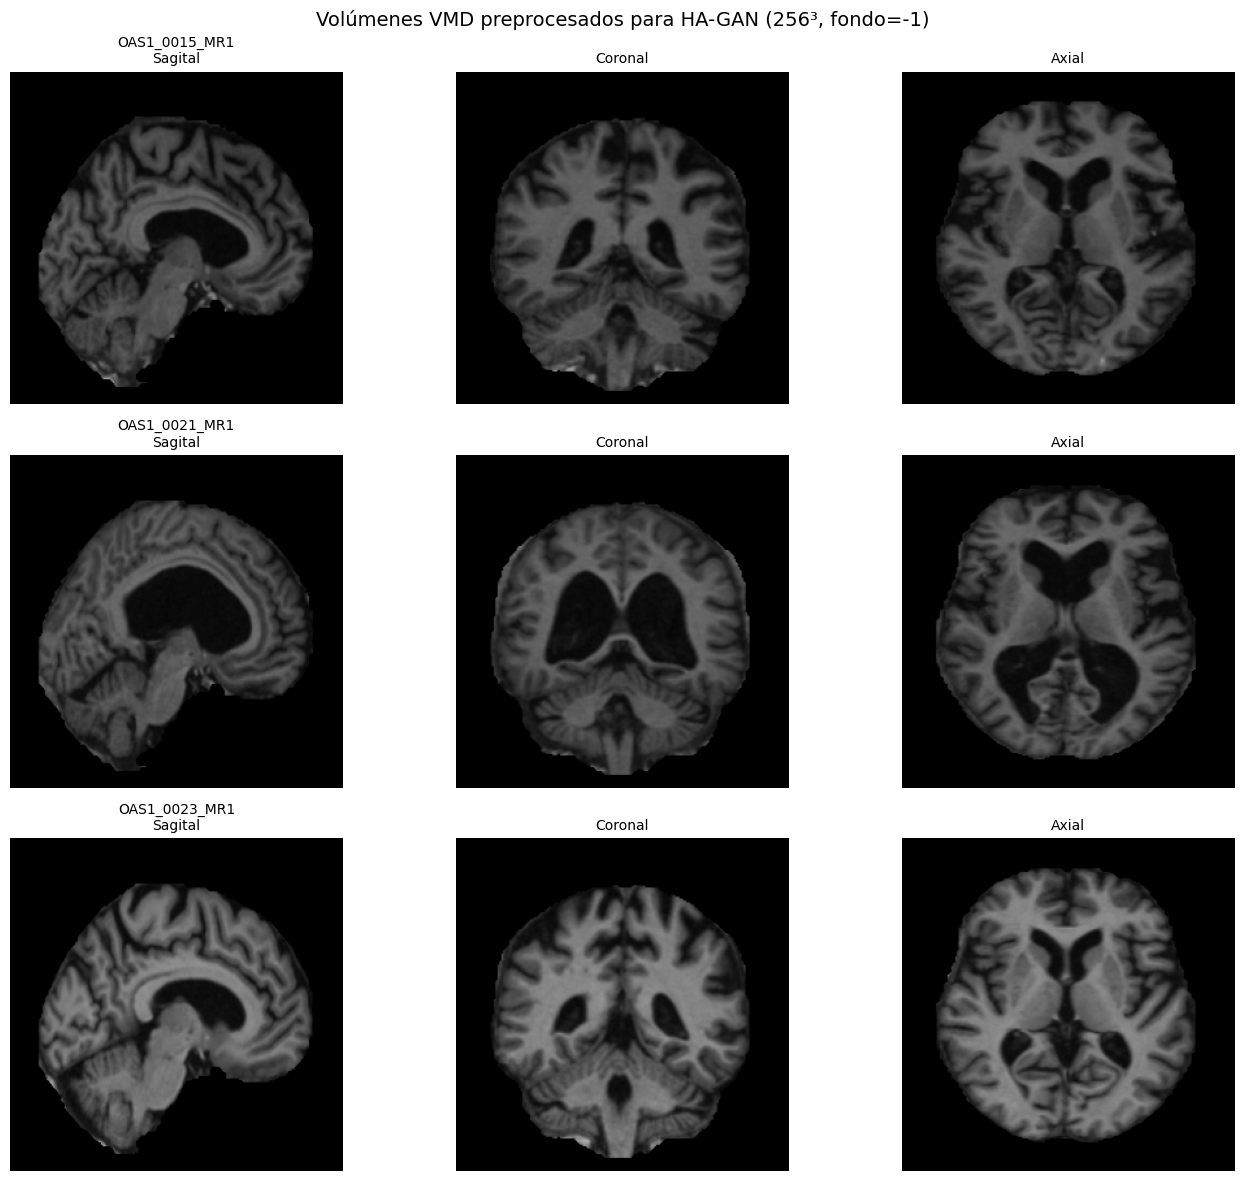

Verificación visual guardada.


In [ ]:
#  3 sujetos VMD preprocesados
sample_files = sorted(glob.glob(os.path.join(VMD_NPY_DIR, '*.npy')))[:3]

# Umbral de fondo para volúmenes en [-1,1] con fondo anclado en -1
BG_THRESH = -0.95

fig, axes = plt.subplots(len(sample_files), 3, figsize=(14, 4 * len(sample_files)))
fig.suptitle('Volúmenes VMD preprocesados para HA-GAN (256³, fondo=-1)', fontsize=14)

for row_i, fpath in enumerate(sample_files):
    vol  = np.load(fpath)
    name = os.path.basename(fpath).replace('.npy', '')

    # Elegir cortes con más tejido (no el centro fijo, que puede caer en zona vacía)
    def slice_con_tejido(v, axis):
        frac = (np.moveaxis(v, axis, 0) > BG_THRESH).mean(axis=(1, 2))
        return int(np.argmax(frac))

    ix = slice_con_tejido(vol, 0)
    iy = slice_con_tejido(vol, 1)
    iz = slice_con_tejido(vol, 2)

    slices  = [vol[ix, :, :], vol[:, iy, :], vol[:, :, iz]]
    titulos = [f'{name}\nSagital', 'Coronal', 'Axial']

    for col_i, (sl, tit) in enumerate(zip(slices, titulos)):
        ax = axes[row_i, col_i] if len(sample_files) > 1 else axes[col_i]
        # Mostrar tejido: rango [-1, 1] mapea fondo->negro, tejido brillante->blanco
        ax.imshow(sl.T, cmap='gray', origin='lower', vmin=-1, vmax=1)
        ax.set_title(tit, fontsize=10)
        ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'vmd_preprocessed_check.png'), dpi=100, bbox_inches='tight')
plt.show()
print('Verificación visual guardada.')

## 4. Fine-tuning HA-GAN sobre Volúmenes VMD

Se carga el checkpoint GSP Brain MRI (3,538 cerebros T1) y se continúa el entrenamiento con los volúmenes VMD del split de train.


Se confirma que el repositorio se ha clonado correctamente, que las rutas del sistema apuntan al directorio adecuado y se conocen los hiperparámetros disponibles que se pueden sobreescribir más adelante

In [ ]:
# print los argumentos disponibles en train.py de HA-GAN
train_script = os.path.join(HAGAN_DIR, 'train.py')

if os.path.exists(train_script):
    result = subprocess.run(
        [sys.executable, train_script, '--help'],
        capture_output=True, text=True
    )
    print(result.stdout[:3000] if result.stdout else result.stderr[:3000])
else:
    print(f'train.py no encontrado en: {HAGAN_DIR}')
    print('Verifica que HA-GAN fue clonado correctamente y que sys.path apunta a src/')

usage: train.py [-h] [--batch-size BATCH_SIZE] [--workers WORKERS]
                [--img-size IMG_SIZE] [--num-iter NUM_ITER]
                [--log-iter LOG_ITER] [--continue-iter CONTINUE_ITER]
                [--latent-dim LATENT_DIM] [--g-iter G_ITER] [--lr-g LR_G]
                [--lr-d LR_D] [--lr-e LR_E] [--data-dir DATA_DIR]
                [--exp-name EXP_NAME] [--fold FOLD]
                [--lambda-class LAMBDA_CLASS] [--num-class NUM_CLASS]

PyTorch HA-GAN Training

options:
  -h, --help            show this help message and exit
  --batch-size BATCH_SIZE
                        mini-batch size (default: 4), this is the total batch
                        size of all GPUs
  --workers WORKERS     number of data loading workers (default: 8)
  --img-size IMG_SIZE   size of training images (default: 256, can be 128 or
                        256)
  --num-iter NUM_ITER   number of iteration for training (default: 80000)
  --log-iter LOG_ITER   number of iteration between loggi

Revisión GPU y validación de memoria

In [ ]:
import torch

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem  = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'GPU: {gpu_name} ({gpu_mem:.1f} GB VRAM)')

    if gpu_mem < 20:
        print('ADVERTENCIA: GPU < 20GB. Fine-tuning puede fallar.')
        print('Cambiar entorno ejecucion o n-iter a 3000.')
    else:
        print('GPU suficiente para fine-tuning a 256x256x256.')
else:
    print('No se detectó GPU. Activar GPU en Entorno de ejecución.')

GPU: Tesla T4 (15.6 GB VRAM)
ADVERTENCIA: GPU < 20GB. Fine-tuning puede fallar.
Cambiar entorno ejecucion o n-iter a 3000.


## **No volver a correr NUNCA, el fine tuning duro casi 5 horas**

En este bloque se realiza el transfer learning de HA-GAN sobre los volúmenes VMD. El flujo de la celda es:

1. Se definen los hiperparámetros del experimento (nombre, iteración base del checkpoint GSP, número de iteraciones de fine-tuning, batch size, learning rates y frecuencia de log) y se crean en Drive las carpetas de checkpoints principal y de respaldo.
2. Se importan las arquitecturas Generator (G), Discriminator (D), Encoder (E) y Sub_Encoder (Sub_E) desde el repositorio clonado de HA-GAN.
3. Se abre el checkpoint comprimido GSP (gzip + tar), se recorren sus miembros y se extraen los state_dicts correspondientes a G, D, E y Sub_E.
4. Se instancian los cuatro modelos junto con sus optimizadores Adam, se cargan los pesos del GSP en cada uno y se guardan como checkpoints base de la iteración 80000, tanto en el directorio local que usa train.py como en las dos carpetas de Drive.
5. Se verifica que los checkpoints base existan en local, mostrando su tamaño y confirmando que el optimizador conserva sus param_groups.
6. Se inspecciona la carpeta de .npy del split VMD, calculando el número aproximado de muestras del fold de entrenamiento y validando que sean suficientes para el batch size elegido.
7. Se toma un snapshot de los .pth existentes y se lanza train.py como subproceso con los argumentos del fine-tuning (continue-iter=80000, num-iter=88000, lr-g=1e-5, lr-d=4e-5), imprimiendo el log de entrenamiento.
8. Al finalizar, se identifican los checkpoints nuevos generados durante el fine-tuning y se copian a la carpeta principal y a la de respaldo en Drive, listando al final los G_iter*.pth disponibles en ambas ubicaciones.

In [ ]:
import torch, torch.nn as nn, torch.optim as optim
import gzip, io, tarfile, os, sys, subprocess, glob, shutil

EXP_NAME  = 'ha_gan_vmd'
GSP_ITER  = 80000
N_ITER    = 8000
WORKERS   = 2
LOG_EVERY = 500
BATCH_SIZE = 2

DRIVE_CKPT_DIR   = os.path.join(OUTPUT_DIR, 'checkpoints_vmd')
DRIVE_BACKUP_DIR = os.path.join(OUTPUT_DIR, 'checkpoints_vmd_backup')
os.makedirs(DRIVE_CKPT_DIR,   exist_ok=True)
os.makedirs(DRIVE_BACKUP_DIR, exist_ok=True)

def guardar_en_drive(src_path):
    fname = os.path.basename(src_path)
    for dst_dir in (DRIVE_CKPT_DIR, DRIVE_BACKUP_DIR):
        dst = os.path.join(dst_dir, fname)
        shutil.copy2(src_path, dst)
    mb = os.path.getsize(src_path) / 1e6
    print(f'  → {fname:24s} {mb:7.1f} MB  copiado a checkpoints_vmd/ y checkpoints_vmd_backup/')

if HAGAN_DIR not in sys.path:
    sys.path.insert(0, HAGAN_DIR)

from models.Model_HA_GAN_256 import Discriminator, Generator, Encoder, Sub_Encoder
from utils import trim_state_dict_name

gsp_components = {}

with gzip.open(GSP_CKPT_PATH, 'rb') as f_gz:
    inner_bytes = f_gz.read()

buf = io.BytesIO(inner_bytes)
with tarfile.open(fileobj=buf, mode='r:') as tar:
    for name in tar.getnames():
        member_file = tar.extractfile(name)
        if member_file is None:
            continue
        obj = torch.load(io.BytesIO(member_file.read()),
                         map_location='cpu', weights_only=False)
        basename = os.path.basename(name)
        if   basename.startswith('Sub_E') or basename.startswith('SubE'):
            key = 'Sub_E'
        elif basename.startswith('G_'):
            key = 'G'
        elif basename.startswith('D_'):
            key = 'D'
        elif basename.startswith('E_'):
            key = 'E'
        else:
            continue
        gsp_components[key] = obj
        print(f'  Componente {key:6s} extraído de {basename}')

print(f'\nComponentes encontrados: {sorted(gsp_components.keys())}')

device_prep = torch.device('cpu')

G_tmp     = Generator(mode='train', latent_dim=LATENT_DIM, num_class=0).to(device_prep)
D_tmp     = Discriminator(num_class=0).to(device_prep)
E_tmp     = Encoder().to(device_prep)
Sub_E_tmp = Sub_Encoder(latent_dim=LATENT_DIM).to(device_prep)

g_opt     = optim.Adam(G_tmp.parameters(),     lr=1e-5, betas=(0.0, 0.999), eps=1e-8)
d_opt     = optim.Adam(D_tmp.parameters(),     lr=4e-5, betas=(0.0, 0.999), eps=1e-8)
e_opt     = optim.Adam(E_tmp.parameters(),     lr=1e-5, betas=(0.0, 0.999), eps=1e-8)
sub_e_opt = optim.Adam(Sub_E_tmp.parameters(), lr=1e-5, betas=(0.0, 0.999), eps=1e-8)

model_map = {
    'G':     (G_tmp,     g_opt),
    'D':     (D_tmp,     d_opt),
    'E':     (E_tmp,     e_opt),
    'Sub_E': (Sub_E_tmp, sub_e_opt),
}

HAGAN_CKPT_DIR = os.path.join(HAGAN_DIR, 'checkpoint', EXP_NAME)
os.makedirs(HAGAN_CKPT_DIR, exist_ok=True)

print('\nGuardando checkpoints base (iter80000)...')
for prefix, (model, optimizer) in model_map.items():
    out_path = os.path.join(HAGAN_CKPT_DIR, f'{prefix}_iter{GSP_ITER}.pth')
    if prefix in gsp_components:
        raw = gsp_components[prefix]
        sd  = raw.get('model', raw) if isinstance(raw, dict) else raw
        sd  = trim_state_dict_name(sd)
        model.load_state_dict(sd, strict=False)
    torch.save(
        {'model': model.state_dict(), 'optimizer': optimizer.state_dict()},
        out_path
    )
    guardar_en_drive(out_path)

del G_tmp, D_tmp, E_tmp, Sub_E_tmp, g_opt, d_opt, e_opt, sub_e_opt, gsp_components

print('\nVerificando archivos en HAGAN_CKPT_DIR (local):')
for prefix in ['G', 'D', 'E', 'Sub_E']:
    p  = os.path.join(HAGAN_CKPT_DIR, f'{prefix}_iter{GSP_ITER}.pth')
    mb = os.path.getsize(p) / 1e6
    ckpt_check = torch.load(p, map_location='cpu', weights_only=False)
    has_pg = 'param_groups' in ckpt_check.get('optimizer', {})
    print(f'  {prefix}_iter{GSP_ITER}.pth : {mb:.1f} MB  optimizer.param_groups={"✓" if has_pg else "✗"}')

DATA_DIR_WITH_SLASH = VMD_NPY_DIR.rstrip('/') + '/'
npy_files = [f for f in os.listdir(VMD_NPY_DIR) if f.endswith('.npy')]
print(f'\nArchivos .npy en VMD_NPY_DIR: {len(npy_files)}')
n_train_approx = int(len(npy_files) * 0.8)
print(f'  ~{n_train_approx} muestras en fold train → OK para batch_size={BATCH_SIZE}')
print(f'  data-dir → {DATA_DIR_WITH_SLASH}')

ckpts_antes = set(glob.glob(os.path.join(HAGAN_CKPT_DIR, '*.pth')))

#fine tuning
train_cmd = [
    sys.executable, os.path.join(HAGAN_DIR, 'train.py'),
    '--workers',        str(WORKERS),
    '--img-size',       str(IMG_SIZE),
    '--num-class',      '0',
    '--exp-name',       EXP_NAME,
    '--data-dir',       DATA_DIR_WITH_SLASH,
    '--num-iter',       str(GSP_ITER + N_ITER),
    '--batch-size',     str(BATCH_SIZE),
    '--lr-g',           '1e-5',
    '--lr-d',           '4e-5',
    '--log-iter',       str(LOG_EVERY),
    '--continue-iter',  str(GSP_ITER),
]

print('\nIniciando fine-tuning...')
print('Comando:', ' '.join(train_cmd))

result = subprocess.run(
    train_cmd,
    capture_output=True,
    text=True,
    cwd=HAGAN_DIR
)

if result.stdout:
    print(result.stdout[-6000:])

print(f'\nFine-tuning completado. Checkpoints locales en: {HAGAN_CKPT_DIR}')

print('\nCopiando checkpoints del fine-tuning a Drive (principal + respaldo)...') # copiar checkpoints para no perder el proceso de 5 horas
ckpts_despues = set(glob.glob(os.path.join(HAGAN_CKPT_DIR, '*.pth')))
ckpts_nuevos  = sorted(ckpts_despues - ckpts_antes)

for src in ckpts_nuevos:
    guardar_en_drive(src)

print(f'\nCheckpoints G en Drive principal ({os.path.basename(DRIVE_CKPT_DIR)}):')
for f in sorted(glob.glob(os.path.join(DRIVE_CKPT_DIR, 'G_iter*.pth'))):
    print(f'  {os.path.basename(f):25s}  {os.path.getsize(f)/1e6:.1f} MB')
print(f'\nCheckpoints G en respaldo ({os.path.basename(DRIVE_BACKUP_DIR)}):')
for f in sorted(glob.glob(os.path.join(DRIVE_BACKUP_DIR, 'G_iter*.pth'))):
    print(f'  {os.path.basename(f):25s}  {os.path.getsize(f)/1e6:.1f} MB')

  Componente D      extraído de D_iter80000.pth
  Componente Sub_E  extraído de Sub_E_iter80000.pth
  Componente E      extraído de E_iter80000.pth
  Componente G      extraído de G_iter80000.pth

Componentes encontrados: ['D', 'E', 'G', 'Sub_E']

Guardando checkpoints base (iter80000)...
  → G_iter80000.pth            210.1 MB  copiado a checkpoints_vmd/ y checkpoints_vmd_backup/
  → D_iter80000.pth             29.6 MB  copiado a checkpoints_vmd/ y checkpoints_vmd_backup/
  → E_iter80000.pth              0.6 MB  copiado a checkpoints_vmd/ y checkpoints_vmd_backup/
  → Sub_E_iter80000.pth         78.7 MB  copiado a checkpoints_vmd/ y checkpoints_vmd_backup/

Verificando archivos en HAGAN_CKPT_DIR (local):
  G_iter80000.pth : 210.1 MB  optimizer.param_groups=✓
  D_iter80000.pth : 29.6 MB  optimizer.param_groups=✓
  E_iter80000.pth : 0.6 MB  optimizer.param_groups=✓
  Sub_E_iter80000.pth : 78.7 MB  optimizer.param_groups=✓

Archivos .npy en VMD_NPY_DIR: 49
  ~39 muestras en fold train → 

## 5. Generación de Volúmenes Sintéticos VMD


Se importa la clase Generator desde el código fuente del repositorio de la GAN. Adicionalmente, se verifica la disponibilidad del hardware.

In [ ]:
import torch
import torch.nn as nn
import sys, os

if HAGAN_DIR not in sys.path:
    sys.path.insert(0, HAGAN_DIR)

try:
    from models.Model_HA_GAN_256 import Generator
    print('Generator importado desde models/Model_HA_GAN_256.py')
except ImportError as e:
    print(f'Error al importar Generator: {e}')
    Generator = None

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Generator importado desde models/Model_HA_GAN_256.py
Device: cuda


Se listan todos los checkpoints .pth guardados en Drive con su tamaño, y de los del generador (G_iter*.pth) se distinguen los del modelo base preentrenado (iteración 80,000) y los actualizados por el fine-tuning (iteraciones > 80,000). De estos últimos se selecciona automáticamente el más reciente, que será el checkpoint con las características aprendidas de la clase Very Mild Dementia y el que se usará para generar los volúmenes sintéticos.

In [ ]:
HAGAN_CKPT_DIR = os.path.join(OUTPUT_DIR, 'checkpoints_vmd')

ckpts = sorted(glob.glob(os.path.join(HAGAN_CKPT_DIR, '*.pth')))
print(f'Checkpoints disponibles: {len(ckpts)}')
for c in ckpts:
    mb = os.path.getsize(c) / 1e6
    print(f'  {os.path.basename(c):50s}  {mb:.1f} MB')

gen_ckpts_ft = sorted([
    c for c in ckpts
    if os.path.basename(c).startswith('G_iter')
    and int(os.path.basename(c).replace('G_iter', '').replace('.pth', '')) > GSP_ITER
])

BEST_CKPT = gen_ckpts_ft[-1]
print(f'\n✓ Checkpoint fine-tuning más reciente: {BEST_CKPT}')
print(f'Procediendo a generar con pesos VMD: {os.path.basename(BEST_CKPT)}')

Checkpoints disponibles: 68
  D_iter80000.pth                                     29.6 MB
  D_iter80500.pth                                     88.9 MB
  D_iter81000.pth                                     88.9 MB
  D_iter81500.pth                                     88.9 MB
  D_iter82000.pth                                     88.9 MB
  D_iter82500.pth                                     88.9 MB
  D_iter83000.pth                                     88.9 MB
  D_iter83500.pth                                     88.9 MB
  D_iter84000.pth                                     88.9 MB
  D_iter84500.pth                                     88.9 MB
  D_iter85000.pth                                     88.9 MB
  D_iter85500.pth                                     88.9 MB
  D_iter86000.pth                                     88.9 MB
  D_iter86500.pth                                     88.9 MB
  D_iter87000.pth                                     88.9 MB
  D_iter87500.pth                         

En esta parte se prepara los metadatos médicos reales para que cuando la GAN genere un cerebro tenga este header y se guarde como un archivo .nii.gz

In [ ]:
# Cargar header de referencia de un sujeto VMD real para que los sintéticos tengan la misma información espacial

ref_subject = df_vmd_train['ID'].iloc[0]
ref_hdr_path = find_t88_path(ref_subject, DISCS_ROOT)

assert ref_hdr_path is not None, f'No se encontró el sujeto de referencia {ref_subject}'

ref_img     = nib.load(ref_hdr_path)
ref_affine  = ref_img.affine
ref_header  = ref_img.header.copy()

# ajustar dimensiones del header para que coincida con el volumen generado
ref_header_256 = ref_header.copy()
ref_header_256.set_data_shape(TARGET_SIZE + (1,))

print(f'Header de referencia: sujeto {ref_subject}')
print(f'Affine:\n{ref_affine}')

Header de referencia: sujeto OAS1_0243_MR1
Affine:
[[  -1.     0.     0.    87.5]
 [   0.     1.     0.  -103.5]
 [   0.     0.     1.   -87.5]
 [   0.     0.     0.     1. ]]


Se carga el generador entrenado y produce los volúmenes sintéticos VMD:

1. Se instancia el Generator de HA-GAN en modo test, que ensambla el volumen completo de 256×256×256 vóxeles en una sola pasada a partir del vector latente z.
2. Se carga el checkpoint seleccionado, se extrae el state_dict y se aplica trim_state_dict_name para eliminar el prefijo module que PyTorch añade cuando el modelo se entrenó con DataParallel.
3. Se hace una pasada de prueba con un vector z aleatorio y se reporta el shape de salida, el rango de valores y la fracción de vóxeles no cero, para confirmar que el generador produce señal anatómica.
4. Se definen dos funciones: generate_synthetic_volume, que muestrea un vector z y devuelve el volumen 3D del generador como float32 en [-1, 1], y denormalize_volume, que reescala linealmente la salida de la tanh al rango [0, 255] y ancla en 0 los vóxeles por debajo del 5% para no inflar artificialmente la fracción de tejido.
5. Se borran los sintéticos previos en SYNTH_NII_DIR y se ejecuta un bucle de N_SYNTH iteraciones que genera el volumen normalizado, lo desnormaliza, lo envuelve en un NIfTI con el affine y el header de referencia del sujeto VMD real definido anteriormente y lo guarda como synthetic_VMD_XXXX.nii.gz, reportando progreso cada 10 muestras con la fracción de tejido y el rango de intensidades.

In [ ]:
import torch
from models.Model_HA_GAN_256 import Generator
from utils import trim_state_dict_name

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

G = Generator(mode='test', latent_dim=LATENT_DIM, num_class=0).to(device)

ckpt = torch.load(BEST_CKPT, map_location=device, weights_only=False)

if isinstance(ckpt, dict) and 'model' in ckpt:
    sd = ckpt['model']
    print("  Usando clave 'model' del checkpoint")
else:
    sd = ckpt

sd = trim_state_dict_name(sd)
missing, unexpected = G.load_state_dict(sd, strict=False)
G.eval()

print(f'Generador cargado desde: {os.path.basename(BEST_CKPT)}')
print(f'  Missing keys   : {len(missing)}')
print(f'  Unexpected keys: {len(unexpected)}')
n_params = sum(p.numel() for p in G.parameters()) / 1e6
print(f'  Parámetros     : {n_params:.1f} M')

print('\nVerificación con 1 volumen de prueba...')
with torch.no_grad():
    z_test = torch.randn(1, LATENT_DIM).to(device)
    out_test = G(z_test, 0)
vol_test = out_test.squeeze().cpu().numpy()
print(f'  Shape salida    : {out_test.shape}')
print(f'  Rango           : [{vol_test.min():.4f}, {vol_test.max():.4f}]')
print(f'  Fracción no-cero: {(vol_test != 0).mean():.2%}')
print('Verificación Ok, generador produce señal anatómica.\n')


def generate_synthetic_volume(G, device, latent_dim, seed=None):
    if seed is not None:
        torch.manual_seed(seed)
    G.eval()
    with torch.no_grad():
        z = torch.randn(1, latent_dim).to(device)
        output = G(z, 0)
    vol = output.squeeze().cpu().numpy()
    return vol.astype(np.float32)


def denormalize_volume(vol_normalized, out_min=0.0, out_max=255.0):
    vol = np.clip(vol_normalized, -1.0, 1.0)
    vol = (vol + 1.0) / 2.0
    vol = vol * (out_max - out_min) + out_min
    fondo_thresh = out_min + 0.05 * (out_max - out_min)
    vol[vol < fondo_thresh] = out_min
    return vol.astype(np.float32)


existing = glob.glob(os.path.join(SYNTH_NII_DIR, '*.nii.gz'))
if existing:
    for f in existing:
        os.remove(f)
    print(f'{len(existing)} sintéticos anteriores eliminados.')

N_SYNTH = n_generate
print(f'Generando {N_SYNTH} volúmenes sintéticos VMD...')

generated_paths = []
for i in range(N_SYNTH):
    vol_norm = generate_synthetic_volume(G, device, LATENT_DIM, seed=RANDOM_SEED + i)
    vol_real = denormalize_volume(vol_norm, out_min=0.0, out_max=255.0)
    if i == 0:
        print(f'  vol_norm rango: [{vol_norm.min():.4f}, {vol_norm.max():.4f}]')
        print(f'  vol_norm fracción > -0.9 (tejido): {(vol_norm > -0.9).mean():.2%}')
        print(f'  vol_real rango: [{vol_real.min():.1f}, {vol_real.max():.1f}]')

    out_name = f'synthetic_VMD_{i+1:04d}.nii.gz'
    out_path = os.path.join(SYNTH_NII_DIR, out_name)
    nii_img  = nib.Nifti1Image(vol_real[..., np.newaxis], affine=ref_affine, header=ref_header_256)
    nib.save(nii_img, out_path)
    generated_paths.append(out_path)

    if (i + 1) % 10 == 0 or i == 0:
        frac_tissue = (vol_real > 30).mean()
        print(f'  {i+1}/{N_SYNTH} — tejido: {frac_tissue:.2%}  '
              f'rango: [{vol_real.min():.1f}, {vol_real.max():.1f}]')

print(f'\nGeneración completa. Guardados en: {SYNTH_NII_DIR}')

  Usando clave 'model' del checkpoint
Generador cargado desde: G_iter88000.pth
  Missing keys   : 0
  Unexpected keys: 0
  Parámetros     : 52.5 M

Verificación con 1 volumen de prueba...
  Shape salida    : torch.Size([1, 1, 256, 256, 256])
  Rango           : [-1.0000, 0.6860]
  Fracción no-cero: 100.00%
Verificación Ok, generador produce señal anatómica.

60 sintéticos anteriores eliminados.
Generando 60 volúmenes sintéticos VMD...
  vol_norm rango: [-1.0000, 0.7102]
  vol_norm fracción > -0.9 (tejido): 23.31%
  vol_real rango: [0.0, 218.0]
  1/60 — tejido: 21.09%  rango: [0.0, 218.0]
  10/60 — tejido: 20.27%  rango: [0.0, 214.6]
  20/60 — tejido: 21.22%  rango: [0.0, 210.5]
  30/60 — tejido: 20.30%  rango: [0.0, 217.2]
  40/60 — tejido: 20.42%  rango: [0.0, 215.2]
  50/60 — tejido: 21.14%  rango: [0.0, 212.3]
  60/60 — tejido: 20.13%  rango: [0.0, 207.3]

Generación completa. Guardados en: /content/drive/MyDrive/Proyecto imagenes y vision/OASIS_Augmentation/synthetic_vmd


## 6. Validación Visual

Antes de incluir los sintéticos en el entrenamiento, se verifica visualmente los volúmenes generados y que su distribución de intensidades sea similar a la de los volúmenes reales VMD.

Se muestran los primeros 4 volúmenes reales y los primeros 4 sintéticos. De cada volumen se muestran tres cortes anatómicos (sagital, coronal y axial), eligiendo en cada eje el corte con mayor fracción de tejido dentro del rango central 20–80% del volumen para evitar las rebanadas casi vacías de los extremos.

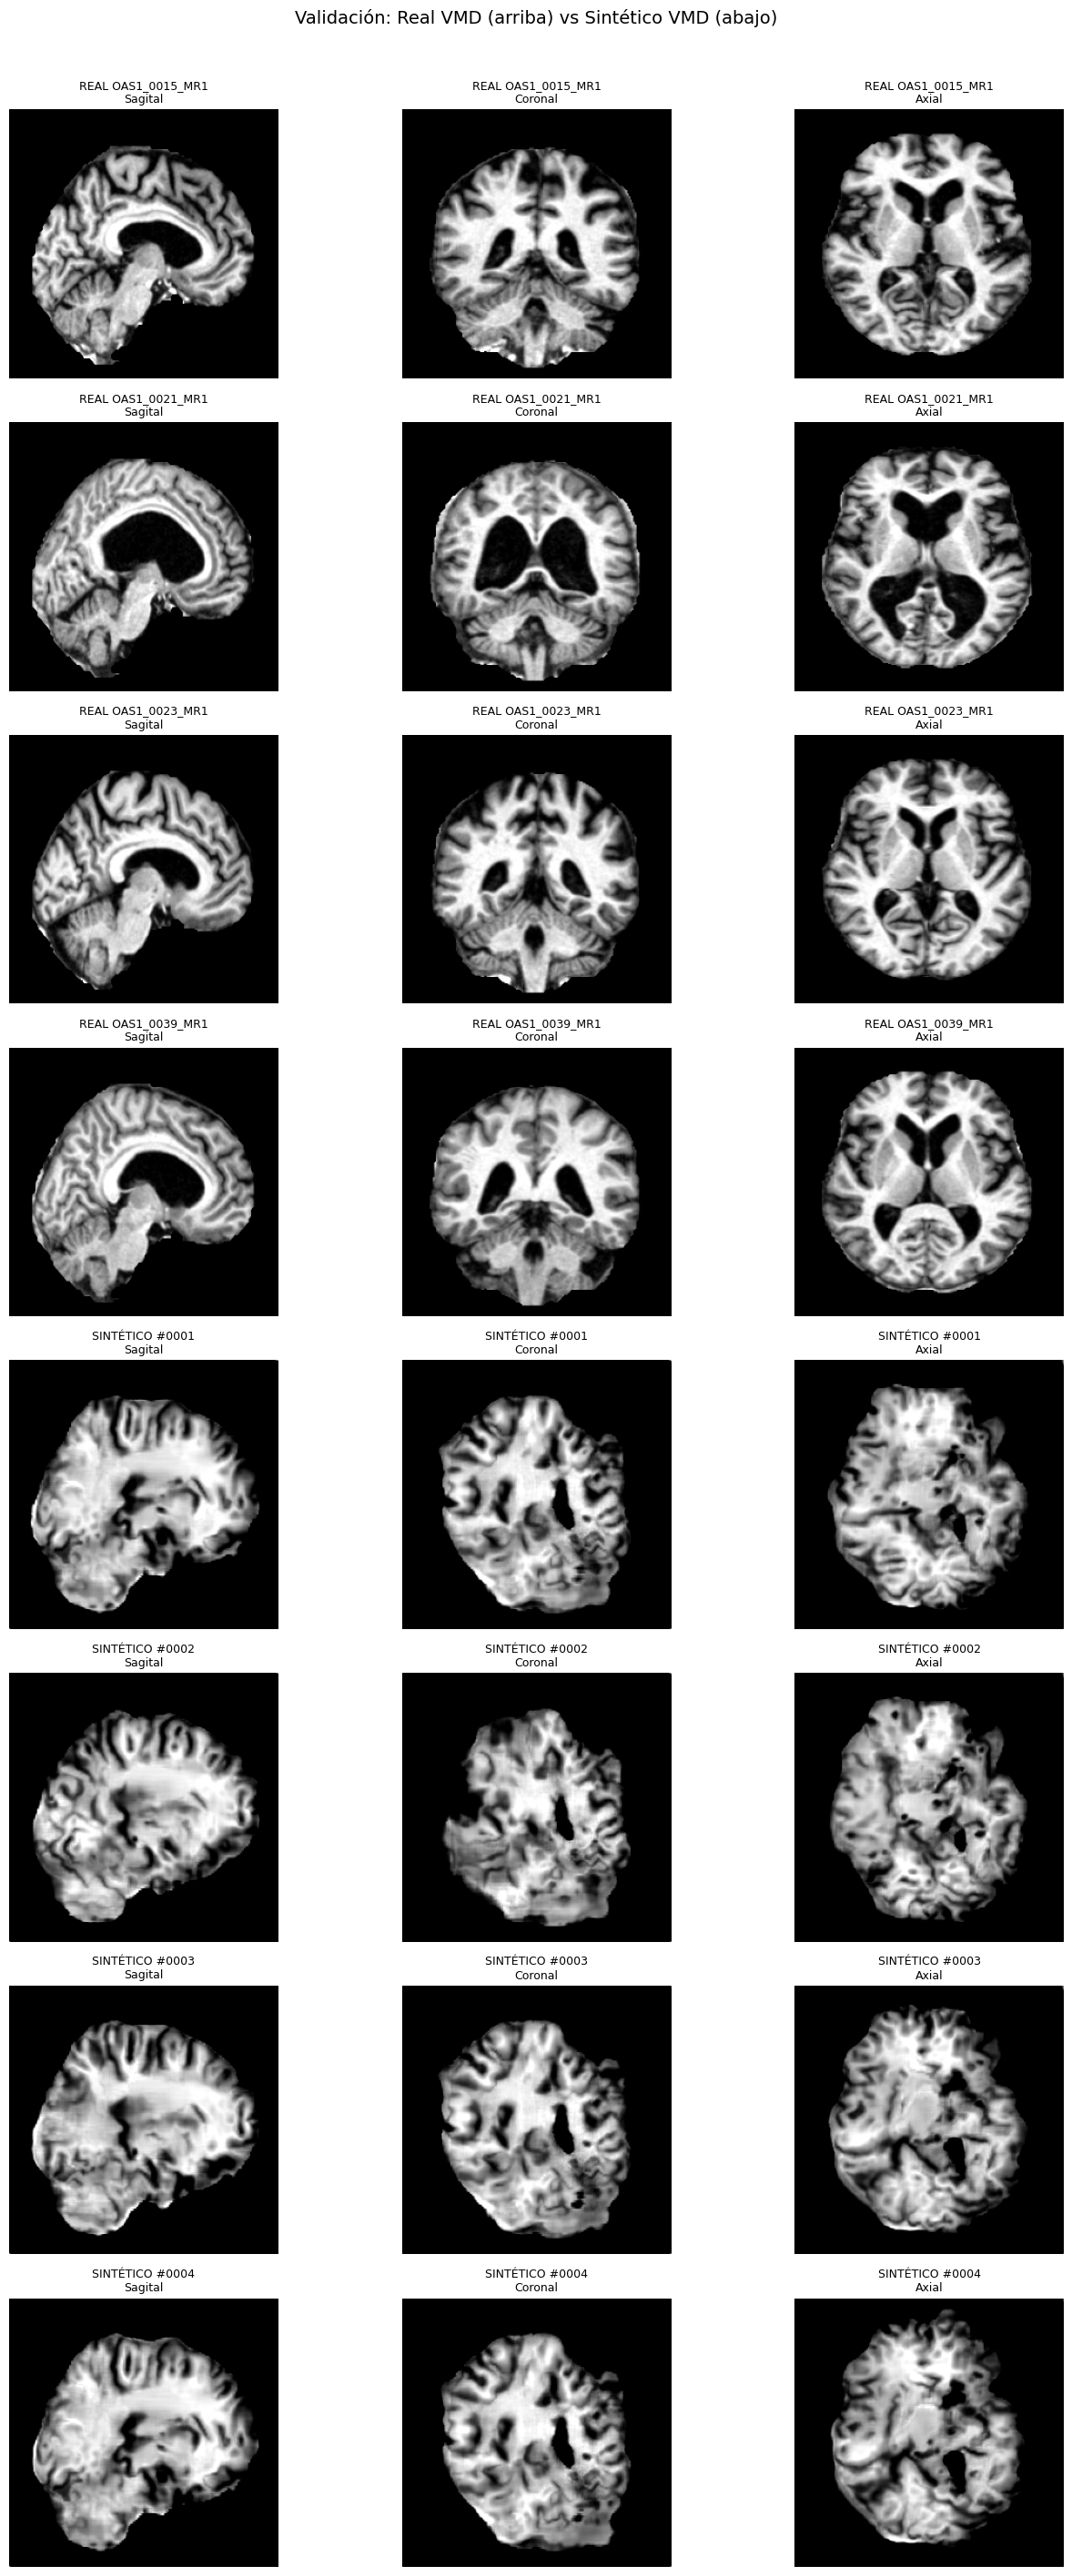

Panel de validación guardado.


In [ ]:
real_paths  = sorted(glob.glob(os.path.join(VMD_NPY_DIR,   '*.npy')))[:4]
synth_paths = sorted(glob.glob(os.path.join(SYNTH_NII_DIR, '*.nii.gz')))[:4]

n_cols = 3
n_rows = len(real_paths) + len(synth_paths)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3.5 * n_rows))
fig.suptitle('Validación: Real VMD (arriba) vs Sintético VMD (abajo)', fontsize=14, y=1.01)


def best_slice(vol, axis, bg_thresh):
    tissue_per_slice = (np.moveaxis(vol, axis, 0) > bg_thresh).mean(axis=(1, 2))
    n = len(tissue_per_slice)
    lo, hi = int(0.20 * n), int(0.80 * n)
    return lo + int(np.argmax(tissue_per_slice[lo:hi]))


def get_anatomical_slices(vol, bg_thresh):
    i0 = best_slice(vol, axis=0, bg_thresh=bg_thresh)
    i1 = best_slice(vol, axis=1, bg_thresh=bg_thresh)
    i2 = best_slice(vol, axis=2, bg_thresh=bg_thresh)
    return vol[i0, :, :], vol[:, i1, :], vol[:, :, i2]


def normalize_for_display(sl, bg_thresh):
    tissue = sl[sl > bg_thresh]
    if tissue.size < 10:
        return np.zeros_like(sl, dtype=np.float32)
    vmin = np.percentile(tissue, 2)
    vmax = np.percentile(tissue, 98)
    out = np.clip((sl - vmin) / (vmax - vmin + 1e-8), 0, 1)
    out[sl <= bg_thresh] = 0.0
    return out.astype(np.float32)

BG_REAL  = -0.95
BG_SYNTH = 10.0

row = 0

for fpath in real_paths:
    vol  = np.load(fpath)
    name = os.path.basename(fpath).replace('.npy', '')
    slices = get_anatomical_slices(vol, bg_thresh=BG_REAL)
    for col, (sl, label) in enumerate(zip(slices, ['Sagital', 'Coronal', 'Axial'])):
        axes[row, col].imshow(normalize_for_display(sl, BG_REAL).T,
                              cmap='gray', origin='lower', vmin=0, vmax=1)
        axes[row, col].set_title(f'REAL {name}\n{label}', fontsize=9)
        axes[row, col].axis('off')
    row += 1

for fpath in synth_paths:
    vol = np.squeeze(nib.load(fpath).get_fdata()).astype(np.float32)
    idx = os.path.basename(fpath).replace('synthetic_VMD_', '').replace('.nii.gz', '')
    slices = get_anatomical_slices(vol, bg_thresh=BG_SYNTH)
    for col, (sl, label) in enumerate(zip(slices, ['Sagital', 'Coronal', 'Axial'])):
        axes[row, col].imshow(normalize_for_display(sl, BG_SYNTH).T,
                              cmap='gray', origin='lower', vmin=0, vmax=1)
        axes[row, col].set_title(f'SINTÉTICO #{idx}\n{label}', fontsize=9)
        axes[row, col].axis('off')
    row += 1

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'validation_real_vs_synth.png'),
            dpi=100, bbox_inches='tight')
plt.show()
print('Panel de validación guardado.')

Comparación de distribución de intensidades Real vs Sintético

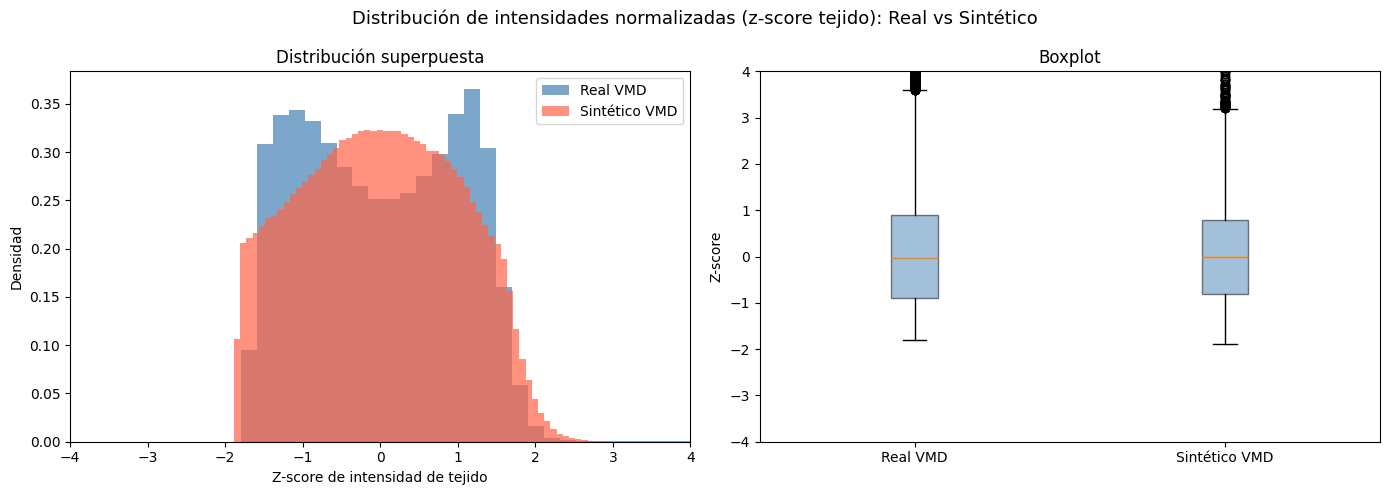

Real  (z-score) — media: 0.0005  std: 1.0006
Synth (z-score) — media: -0.0000  std: 0.9998

Nota: los .nii.gz sintéticos siguen guardados en escala [0,255].
El clasificador aplicará z-score por instancia a todos los volúmenes (reales y sintéticos),
por lo que la diferencia de escala se elimina en el pipeline de entrenamiento.


In [ ]:
def normalize_for_comparison(vol, tissue_threshold):
    tissue = vol[vol > tissue_threshold]
    if len(tissue) == 0 or tissue.std() == 0:
        return None
    return (tissue - tissue.mean()) / tissue.std()


real_intensities  = []
synth_intensities = []

for fpath in sorted(glob.glob(os.path.join(VMD_NPY_DIR, '*.npy'))):
    vol = np.load(fpath)
    z   = normalize_for_comparison(vol, tissue_threshold=-0.5)
    if z is not None:
        real_intensities.extend(z.ravel()[::100])

for fpath in sorted(glob.glob(os.path.join(SYNTH_NII_DIR, '*.nii.gz'))):
    vol = np.squeeze(nib.load(fpath).get_fdata())
    z   = normalize_for_comparison(vol, tissue_threshold=30)
    if z is not None:
        synth_intensities.extend(z.ravel()[::100])


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribución de intensidades normalizadas (z-score tejido): Real vs Sintético',
             fontsize=13)

axes[0].hist(real_intensities,  bins=80, color='steelblue', alpha=0.7, density=True, label='Real VMD')
axes[0].hist(synth_intensities, bins=80, color='tomato',    alpha=0.7, density=True, label='Sintético VMD')
axes[0].set_xlabel('Z-score de intensidad de tejido'); axes[0].set_ylabel('Densidad')
axes[0].legend(); axes[0].set_title('Distribución superpuesta')
axes[0].set_xlim(-4, 4)

axes[1].boxplot(
    [real_intensities, synth_intensities],
    labels=['Real VMD', 'Sintético VMD'],
    patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.5)
)
axes[1].set_ylabel('Z-score'); axes[1].set_title('Boxplot')
axes[1].set_ylim(-4, 4)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'intensity_distribution.png'), dpi=100, bbox_inches='tight')
plt.show()

print(f'Real  (z-score) — media: {np.mean(real_intensities):.4f}  std: {np.std(real_intensities):.4f}')
print(f'Synth (z-score) — media: {np.mean(synth_intensities):.4f}  std: {np.std(synth_intensities):.4f}')
print('\nNota: los .nii.gz sintéticos siguen guardados en escala [0,255].')
print('El clasificador aplicará z-score por instancia a todos los volúmenes (reales y sintéticos),')
print('por lo que la diferencia de escala se elimina en el pipeline de entrenamiento.')

Filtro para revisar volumenes sinteticos aceptados y descartados

Evaluando 60 volúmenes sintéticos...
Objetivo: seleccionar los 45 mejores

Referencia reales — fracción tejido: 0.260 ± 0.000
Rank  Nombre                          Tejido  Contraste  Similitud   Score
────────────────────────────────────────────────────────────────────────
✓1    synthetic_VMD_0015.nii.gz        0.234      109.1      0.000   0.997
✓2    synthetic_VMD_0020.nii.gz        0.234      109.1      0.000   0.993
✓3    synthetic_VMD_0022.nii.gz        0.234      109.1      0.000   0.971
✓4    synthetic_VMD_0045.nii.gz        0.234      108.8      0.000   0.968
✓5    synthetic_VMD_0011.nii.gz        0.234      109.0      0.000   0.968
✓6    synthetic_VMD_0050.nii.gz        0.233      109.0      0.000   0.964
✓7    synthetic_VMD_0035.nii.gz        0.233      109.1      0.000   0.960
✓8    synthetic_VMD_0016.nii.gz        0.233      109.0      0.000   0.957
✓9    synthetic_VMD_0001.nii.gz        0.233      109.0      0.000   0.954
✓10   synthetic_VMD_0036.nii.gz        0.234      1

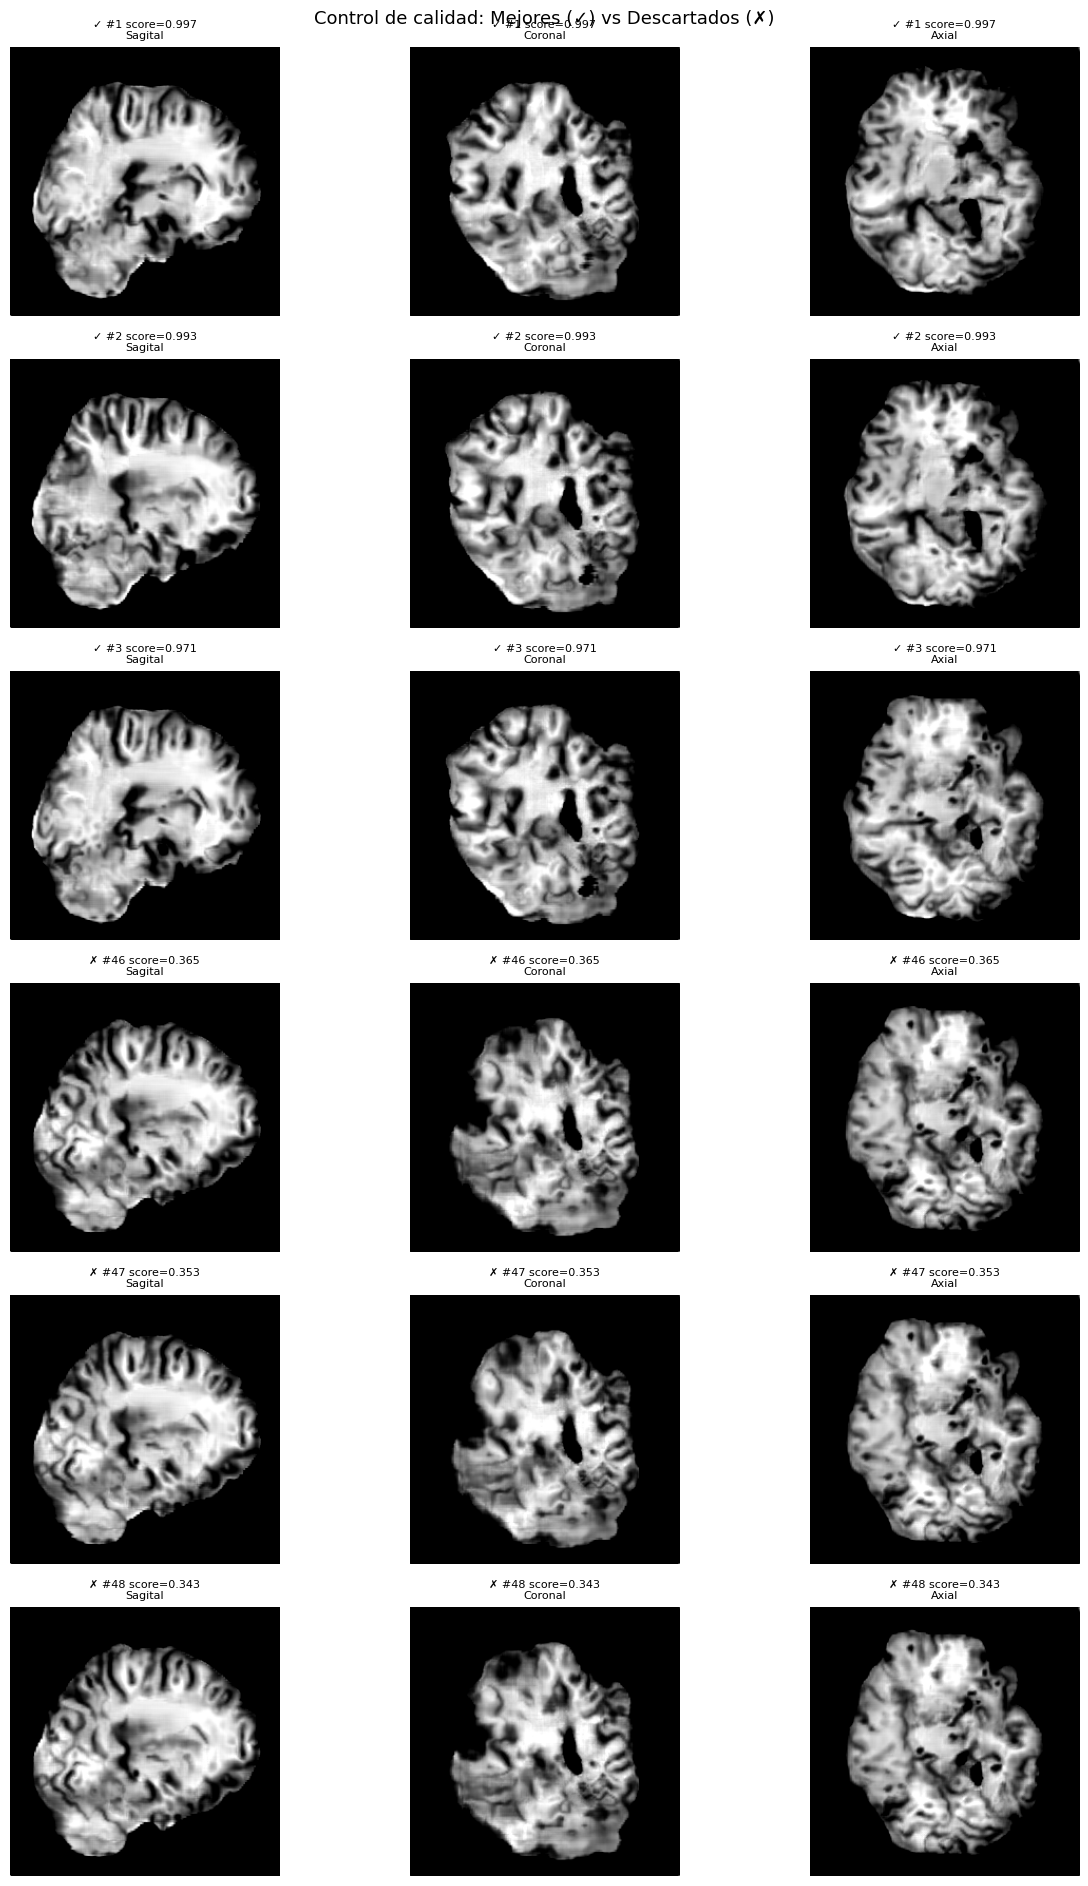

Panel de control de calidad guardado.


In [ ]:
N_KEEP       = n_needed
SIGNAL_MIN   = 10.0
N_CANDIDATES = len(sorted(glob.glob(os.path.join(SYNTH_NII_DIR, '*.nii.gz'))))

print(f'Evaluando {N_CANDIDATES} volúmenes sintéticos...')
print(f'Objetivo: seleccionar los {N_KEEP} mejores\n')

real_fracs = []
for fpath in sorted(glob.glob(os.path.join(VMD_NPY_DIR, '*.npy'))):
    vol = np.load(fpath)
    frac = (vol > -0.95).mean()
    real_fracs.append(frac)

real_frac_mean = np.mean(real_fracs)
real_frac_std  = np.std(real_fracs)
print(f'Referencia reales — fracción tejido: {real_frac_mean:.3f} ± {real_frac_std:.3f}')

records = []
for fpath in sorted(glob.glob(os.path.join(SYNTH_NII_DIR, '*.nii.gz'))):
    vol  = np.squeeze(nib.load(fpath).get_fdata()).astype(np.float32)
    name = os.path.basename(fpath)

    frac_tejido = (vol > SIGNAL_MIN).mean()

    p5  = np.percentile(vol,  5)
    p95 = np.percentile(vol, 95)
    contraste = p95 - p5

    similitud = max(0.0, 1.0 - abs(frac_tejido - real_frac_mean) / (real_frac_std * 3 + 1e-8))

    records.append({
        'path'        : fpath,
        'nombre'      : name,
        'frac_tejido' : frac_tejido,
        'contraste'   : contraste,
        'similitud'   : similitud,
    })

df_scores = pd.DataFrame(records)

for col in ['frac_tejido', 'contraste', 'similitud']:
    mn, mx = df_scores[col].min(), df_scores[col].max()
    if mx > mn:
        df_scores[f'{col}_norm'] = (df_scores[col] - mn) / (mx - mn)
    else:
        df_scores[f'{col}_norm'] = 1.0

df_scores['score_final'] = (
    df_scores['frac_tejido_norm'] * 0.35 +
    df_scores['contraste_norm']   * 0.45 +
    df_scores['similitud_norm']   * 0.20
)

df_scores = df_scores.sort_values('score_final', ascending=False).reset_index(drop=True)

df_accepted  = df_scores.iloc[:N_KEEP].copy()
df_discarded = df_scores.iloc[N_KEEP:].copy()

final_synth = df_accepted['path'].tolist()

print(f'{"Rank":<5} {"Nombre":<30} {"Tejido":>7} {"Contraste":>10} {"Similitud":>10} {"Score":>7}')
print('─' * 72)
for i, r in df_scores.iterrows():
    marker = '✓' if i < N_KEEP else '✗'
    print(f'{marker}{i+1:<4} {r["nombre"]:<30} '
          f'{r["frac_tejido"]:>7.3f} {r["contraste"]:>10.1f} '
          f'{r["similitud"]:>10.3f} {r["score_final"]:>7.3f}')

print(f'\n✓ Aceptados : {len(df_accepted)}')
print(f'✗ Descartados: {len(df_discarded)}')
print(f'  Peores descartados: {df_discarded["nombre"].tolist()}')

n_show = min(3, len(df_accepted)), min(3, len(df_discarded))
n_rows = n_show[0] + n_show[1]

fig, axes = plt.subplots(n_rows, 3, figsize=(13, 3.2 * n_rows))
fig.suptitle('Control de calidad: Mejores (✓) vs Descartados (✗)', fontsize=13)

def mostrar_vol(vol_path, ax_row, label, axes):
    vol = np.squeeze(nib.load(vol_path).get_fdata()).astype(np.float32)
    bg  = 10.0
    def best_sl(v, axis):
        frac = (np.moveaxis(v, axis, 0) > bg).mean(axis=(1, 2))
        n = len(frac); lo, hi = int(0.2 * n), int(0.8 * n)
        return lo + int(np.argmax(frac[lo:hi]))
    slices = [vol[best_sl(vol, 0), :, :], vol[:, best_sl(vol, 1), :], vol[:, :, best_sl(vol, 2)]]
    for col, (sl, titulo) in enumerate(zip(slices, ['Sagital', 'Coronal', 'Axial'])):
        tissue = sl[sl > bg]
        if tissue.size > 10:
            v0, v1 = np.percentile(tissue, 2), np.percentile(tissue, 98)
            sl_norm = np.clip((sl - v0) / (v1 - v0 + 1e-8), 0, 1)
            sl_norm[sl <= bg] = 0.0
        else:
            sl_norm = np.zeros_like(sl)
        ax = axes[ax_row, col]
        ax.imshow(sl_norm.T, cmap='gray', origin='lower', vmin=0, vmax=1)
        ax.set_title(f'{label}\n{titulo}', fontsize=8)
        ax.axis('off')

row = 0
for _, r in df_accepted.iloc[:n_show[0]].iterrows():
    score_str = f'✓ #{r.name+1} score={r["score_final"]:.3f}'
    mostrar_vol(r['path'], row, score_str, axes)
    row += 1
for _, r in df_discarded.iloc[:n_show[1]].iterrows():
    score_str = f'✗ #{r.name+1} score={r["score_final"]:.3f}'
    mostrar_vol(r['path'], row, score_str, axes)
    row += 1

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'filtro_calidad_sinteticos.png'),
            dpi=100, bbox_inches='tight')
plt.show()
print('Panel de control de calidad guardado.')

## 7. Dataset Final y CSV para entrenamiento/val/test con data augmentation

Se genera el CSV  que registra todos los sujetos reales y sintéticos con su split y etiqueta. Este CSV es la entrada al notebook de preprocesamiento y entrenamiento del clasificador 3D.

In [ ]:
rows_synthetic = []
for i, fpath in enumerate(final_synth):
    rows_synthetic.append({
        'subject_base': f'synthetic_{i+1:04d}',
        'ID':           f'synthetic_{i+1:04d}',
        'CDR':          0.5,
        'label':        'vmd',
        'split':        'train',
        'tipo':         'synthetic',
        'file_path':    fpath
    })

df_real_final = df_splits.copy()
df_real_final['tipo'] = 'real'

def get_npy_path(row):
    if row['label'] == 'vmd' and row['split'] == 'train':
        npy = os.path.join(VMD_NPY_DIR, f"{row['ID']}.npy")
        if os.path.exists(npy):
            return npy
    p = find_t88_path(row['ID'], DISCS_ROOT)
    return p if p else ''

df_real_final['file_path'] = df_real_final.apply(get_npy_path, axis=1)

print('✓ Todos los sujetos reales tienen file_path asignado.')

df_synthetic = pd.DataFrame(rows_synthetic)
df_augmented = pd.concat([df_real_final, df_synthetic], ignore_index=True)

AUG_CSV = os.path.join(OUTPUT_DIR, 'dataset_augmented.csv')
df_augmented.to_csv(AUG_CSV, index=False)

print('\n=== Dataset Final ===')
summary_final = df_augmented.groupby(['split', 'label', 'tipo']).size().unstack(fill_value=0)
print(summary_final.to_string())

print('\n--- Train (balance final) ---')
train_final = df_augmented[df_augmented['split'] == 'train']
print(train_final['label'].value_counts().to_string())
print(f'\nCSV guardado en: {AUG_CSV}')

✓ Todos los sujetos reales tienen file_path asignado.

=== Dataset Final ===
tipo         real  synthetic
split label                 
test  sano     21          0
      vmd      10          0
train sano     94          0
      vmd      49         45
val   sano     20          0
      vmd      11          0

--- Train (balance final) ---
label
sano    94
vmd     94

CSV guardado en: /content/drive/MyDrive/Proyecto imagenes y vision/OASIS_Augmentation/dataset_augmented.csv


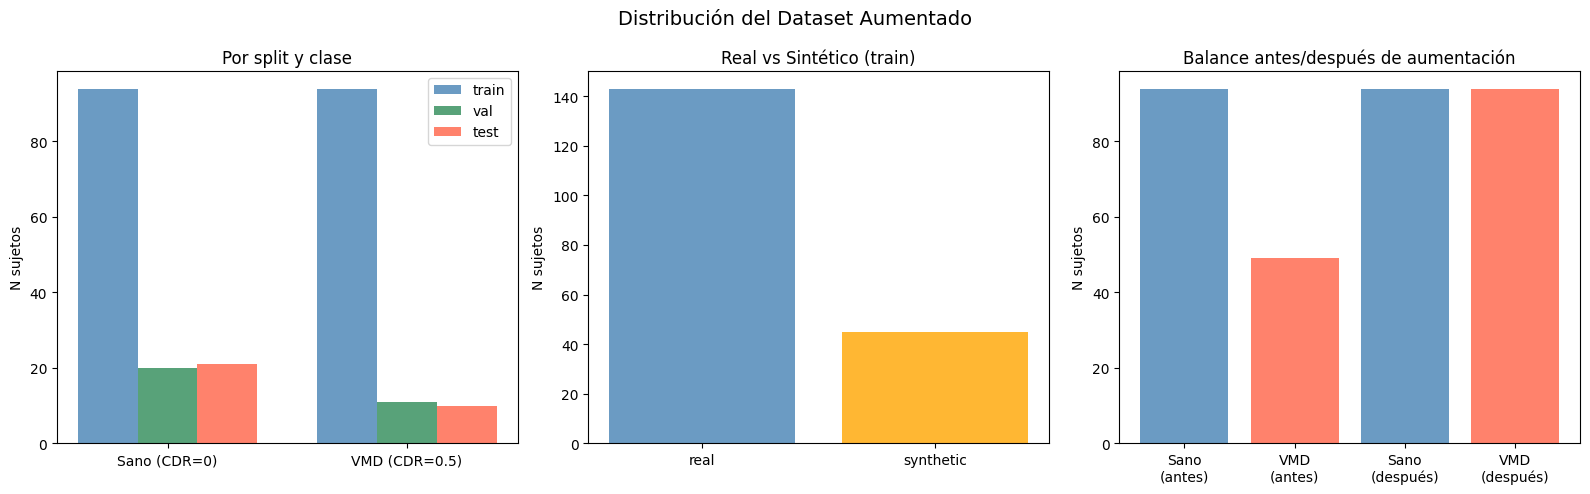


Resumen guardado en: /content/drive/MyDrive/Proyecto imagenes y vision/OASIS_Augmentation
Archivos generados:
  checkpoints_vmd/                                   15632.2 MB
  checkpoints_vmd_backup/                            15632.2 MB
  dataset_augmented.csv                              < 0.1 MB
  dataset_summary.png                                < 0.1 MB
  filtro_calidad_sinteticos.png                      0.7 MB
  gsp_pretrained.pth                                 296.0 MB
  intensity_distribution.png                         < 0.1 MB
  splits_subjects.csv                                < 0.1 MB
  synthetic_vmd/                                     478.6 MB
  validation_real_vs_synth.png                       1.2 MB
  vmd_npy_256/                                       3288.3 MB
  vmd_preprocessed_check.png                         0.4 MB


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Distribución del Dataset Aumentado', fontsize=14)

x     = np.arange(2)
width = 0.25
for i, (split_name, color) in enumerate([('train', 'steelblue'), ('val', 'seagreen'), ('test', 'tomato')]):
    sub    = df_augmented[df_augmented['split'] == split_name]
    counts = [sub[sub['label'] == 'sano'].shape[0],
              sub[sub['label'] == 'vmd'].shape[0]]
    axes[0].bar(x + i * width, counts, width, label=split_name, color=color, alpha=0.8)

axes[0].set_xticks(x + width)
axes[0].set_xticklabels(['Sano (CDR=0)', 'VMD (CDR=0.5)'])
axes[0].set_ylabel('N sujetos')
axes[0].set_title('Por split y clase')
axes[0].legend()

train_data  = df_augmented[df_augmented['split'] == 'train']
tipo_counts = train_data['tipo'].value_counts()
bar_colors  = [('steelblue' if t == 'real' else 'orange') for t in tipo_counts.index]
axes[1].bar(tipo_counts.index, tipo_counts.values, color=bar_colors, alpha=0.8)
axes[1].set_ylabel('N sujetos')
axes[1].set_title('Real vs Sintético (train)')

vmd_before  = df_splits.query("split=='train' and label=='vmd'").shape[0]
sano_before = df_splits.query("split=='train' and label=='sano'").shape[0]
vmd_after   = train_data[train_data['label'] == 'vmd'].shape[0]
sano_after  = train_data[train_data['label'] == 'sano'].shape[0]

axes[2].bar(
    ['Sano\n(antes)', 'VMD\n(antes)', 'Sano\n(después)', 'VMD\n(después)'],
    [sano_before, vmd_before, sano_after, vmd_after],
    color=['steelblue', 'tomato', 'steelblue', 'tomato'],
    alpha=0.8
)
axes[2].set_ylabel('N sujetos')
axes[2].set_title('Balance antes/después de aumentación')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'dataset_summary.png'), dpi=100, bbox_inches='tight')
plt.show()

print(f'\nResumen guardado en: {OUTPUT_DIR}')
print('Archivos generados:')

def get_size_mb(path):
    if os.path.isfile(path):
        return os.path.getsize(path) / 1e6
    elif os.path.isdir(path):
        total = sum(
            os.path.getsize(os.path.join(r, f))
            for r, _, files in os.walk(path)
            for f in files
        )
        return total / 1e6
    return 0.0

for fname in sorted(os.listdir(OUTPUT_DIR)):
    full  = os.path.join(OUTPUT_DIR, fname)
    label = fname + '/' if os.path.isdir(full) else fname
    mb    = get_size_mb(full)
    if mb == 0:
        continue
    print(f'  {label:50s} {"< 0.1 MB" if mb < 0.1 else f"{mb:.1f} MB"}')

## 8. Visualización de Volúmenes del Dataset Final Filtrado

Esta sección carga directamente el CSV final  y muestra 2 volúmenes reales y 2 sintéticos aceptados por el filtro de calidad, con sus cortes sagital, coronal y axial.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
IN_COLAB  : True
OUTPUT_DIR: /content/drive/MyDrive/Proyecto imagenes y vision/OASIS_Augmentation_3D
AUG_CSV   : /content/drive/MyDrive/Proyecto imagenes y vision/OASIS_Augmentation_3D/dataset_augmented.csv
Conteo original por tipo:
tipo
real         205
synthetic     45

Conteo con archivos encontrados por tipo:
tipo
real         205
synthetic     45


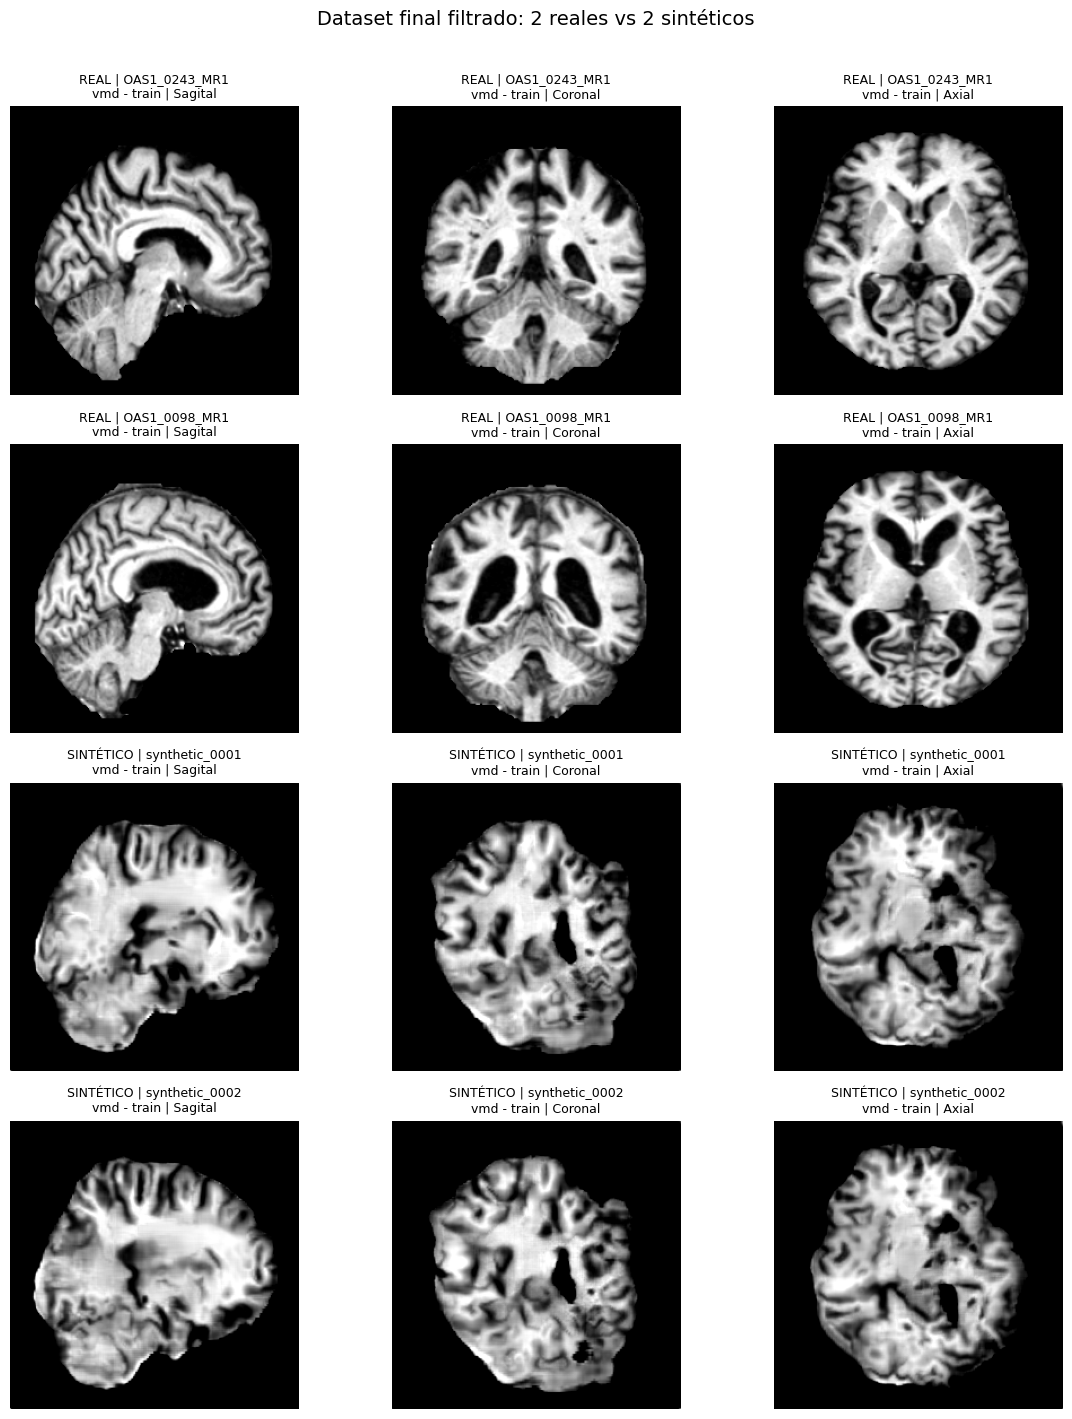

Visualización guardada en: /content/drive/MyDrive/Proyecto imagenes y vision/OASIS_Augmentation_3D/dataset_final_filtrado_2_reales_2_sinteticos.png
            ID      tipo label split                                                                                                       file_path
 OAS1_0243_MR1      real   vmd train           /content/drive/MyDrive/Proyecto imagenes y vision/OASIS_Augmentation_3D/vmd_npy_256/OAS1_0243_MR1.npy
 OAS1_0098_MR1      real   vmd train           /content/drive/MyDrive/Proyecto imagenes y vision/OASIS_Augmentation_3D/vmd_npy_256/OAS1_0098_MR1.npy
synthetic_0001 synthetic   vmd train /content/drive/MyDrive/Proyecto imagenes y vision/OASIS_Augmentation_3D/synthetic_vmd/synthetic_VMD_0015.nii.gz
synthetic_0002 synthetic   vmd train /content/drive/MyDrive/Proyecto imagenes y vision/OASIS_Augmentation_3D/synthetic_vmd/synthetic_VMD_0020.nii.gz


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
IN_COLAB = True

OUTPUT_DIR = '/content/drive/MyDrive/Proyecto imagenes y vision/OASIS_Augmentation_3D' # ESTA RUTA ANTES ERA OASIS_Augmentation, entonces por eso se define nuevamente output_dir, en el proceso la ruta anterior se actualizo
AUG_CSV = os.path.join(OUTPUT_DIR, 'dataset_augmented.csv')

print(f'IN_COLAB  : {IN_COLAB}')
print(f'OUTPUT_DIR: {OUTPUT_DIR}')
print(f'AUG_CSV   : {AUG_CSV}')

df_final_vis = pd.read_csv(AUG_CSV)
df_final_vis['file_path'] = (
    df_final_vis['file_path']
    .astype(str)
    .str.replace('/OASIS_Augmentation/', '/OASIS_Augmentation_3D/', regex=False)
)

print('Conteo original por tipo:')
print(df_final_vis['tipo'].value_counts(dropna=False).to_string())

existing_mask = df_final_vis['file_path'].apply(os.path.exists)
df_final_vis = df_final_vis[existing_mask].copy()

print('\nConteo con archivos encontrados por tipo:')
print(df_final_vis['tipo'].value_counts(dropna=False).to_string())

real_candidates = df_final_vis[
    df_final_vis['tipo'].eq('real')
    & df_final_vis['label'].eq('vmd')
    & df_final_vis['split'].eq('train')
]
synth_candidates = df_final_vis[df_final_vis['tipo'].eq('synthetic')]

rows_to_show = pd.concat([real_candidates.head(2), synth_candidates.head(2)], ignore_index=True)


def load_volume(file_path):
    if file_path.endswith('.npy'):
        vol = np.load(file_path)
    else:
        vol = nib.load(file_path).get_fdata()
    return np.squeeze(vol).astype(np.float32)


def background_threshold(vol, tipo):
    if tipo == 'synthetic':
        return 10.0
    return -0.95 if np.nanmin(vol) < 0 else 0.0


def best_slice(vol, axis, bg_thresh):
    tissue_per_slice = (np.moveaxis(vol, axis, 0) > bg_thresh).mean(axis=(1, 2))
    n = len(tissue_per_slice)
    lo, hi = int(0.20 * n), int(0.80 * n)
    central = tissue_per_slice[lo:hi] if hi > lo else tissue_per_slice
    return (lo + int(np.argmax(central))) if central.size else n // 2


def get_anatomical_slices(vol, bg_thresh):
    i0 = best_slice(vol, 0, bg_thresh)
    i1 = best_slice(vol, 1, bg_thresh)
    i2 = best_slice(vol, 2, bg_thresh)
    return vol[i0, :, :], vol[:, i1, :], vol[:, :, i2]


def normalize_for_display(sl, bg_thresh):
    tissue = sl[sl > bg_thresh]
    if tissue.size < 10:
        return np.zeros_like(sl, dtype=np.float32)
    vmin, vmax = np.percentile(tissue, [2, 98])
    sl_norm = np.clip((sl - vmin) / (vmax - vmin + 1e-8), 0, 1)
    sl_norm[sl <= bg_thresh] = 0.0
    return sl_norm.astype(np.float32)


fig, axes = plt.subplots(4, 3, figsize=(12, 14))
fig.suptitle('Dataset final filtrado: 2 reales vs 2 sintéticos', fontsize=14, y=1.01)
slice_names = ['Sagital', 'Coronal', 'Axial']

for row_idx, (_, row) in enumerate(rows_to_show.iterrows()):
    vol = load_volume(row['file_path'])
    bg = background_threshold(vol, row['tipo'])
    display_type = 'REAL' if row['tipo'] == 'real' else 'SINTÉTICO'

    for col_idx, (sl, slice_name) in enumerate(zip(get_anatomical_slices(vol, bg), slice_names)):
        ax = axes[row_idx, col_idx]
        ax.imshow(normalize_for_display(sl, bg).T, cmap='gray', origin='lower', vmin=0, vmax=1)
        ax.set_title(f"{display_type} | {row['ID']}\n{row['label']} - {row['split']} | {slice_name}", fontsize=9)
        ax.axis('off')

plt.tight_layout()
out_path = os.path.join(OUTPUT_DIR, 'dataset_final_filtrado_2_reales_2_sinteticos.png')
plt.savefig(out_path, dpi=120, bbox_inches='tight')
plt.show()

print(f'Visualización guardada en: {out_path}')
print(rows_to_show[['ID', 'tipo', 'label', 'split', 'file_path']].to_string(index=False))